<a href="https://colab.research.google.com/github/YESHASWINI-R/fertilizer-recommendation-system/blob/main/Fertilizer_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files


In [ ]:
import os
import json

# Load Kaggle credentials
with open('kaggle.json') as f:
    kaggle_credentials = json.load(f)

# Set environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']


In [ ]:
!kaggle datasets download -d jshndeep/fertilizer-recommendation


Dataset URL: https://www.kaggle.com/datasets/jshndeep/fertilizer-recommendation
License(s): unknown
  0% 0.00/1.28k [00:00<?, ?B/s]
100% 1.28k/1.28k [00:00<00:00, 4.99MB/s]


In [ ]:
import zipfile

# Unzip the dataset
with zipfile.ZipFile('fertilizer-recommendation.zip', 'r') as zip_ref:
    zip_ref.extractall()

# List extracted files
os.listdir()


['.config',
 'fertilizer-recommendation.zip',
 '.ipynb_checkpoints',
 'drive',
 'Fertilizer Recommendation.csv',
 'kaggle.json',
 'sample_data']

# Load Dataset

In [ ]:
df = pd.read_csv('Fertilizer Recommendation.csv')

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()
print(df.columns)
print(df.head())


Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')
   Temparature  Humidity  Moisture Soil Type  Crop Type  Nitrogen  Potassium  \
0           26        52        38     Sandy      Maize        37          0   
1           29        52        45     Loamy  Sugarcane        12          0   
2           34        65        62     Black     Cotton         7          9   
3           32        62        34       Red    Tobacco        22          0   
4           28        54        46    Clayey      Paddy        35          0   

   Phosphorous Fertilizer Name  
0            0            Urea  
1           36             DAP  
2           30        14-35-14  
3           20           28-28  
4            0            Urea  


# EDA

In [ ]:
# Check all column names exactly as they appear
print(df.columns)


Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64


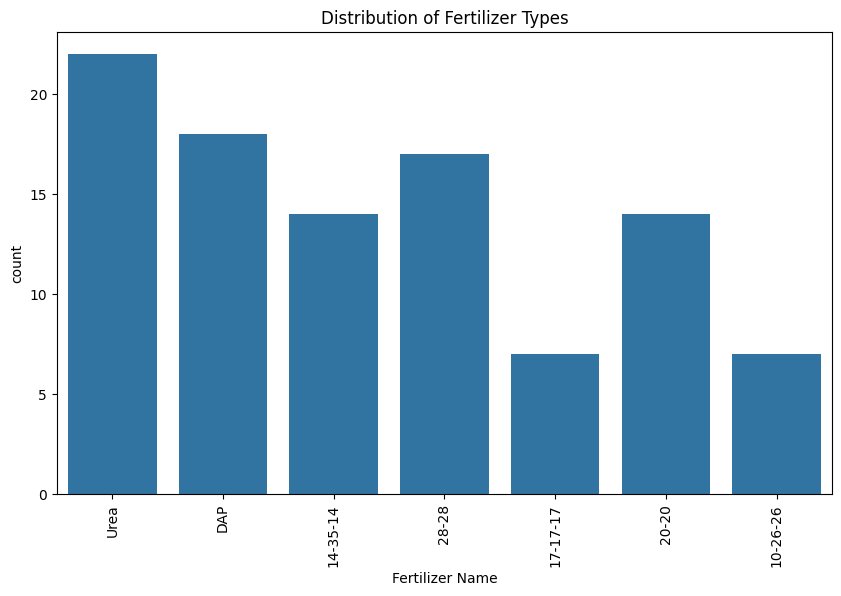

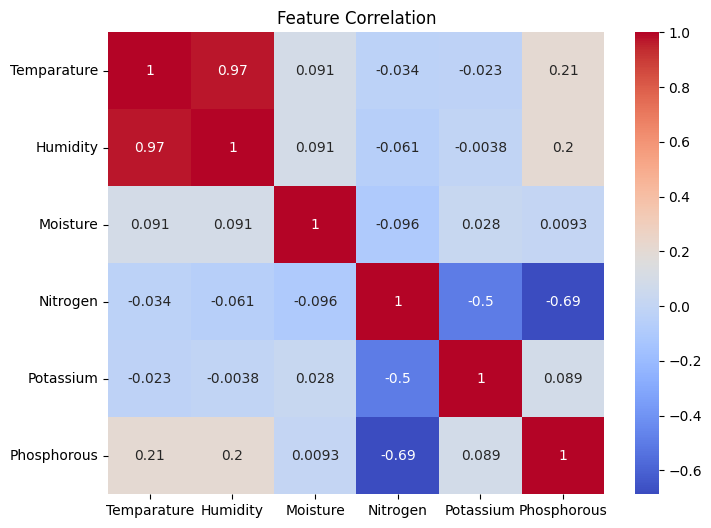

In [ ]:
# Check missing values
print(df.isnull().sum())

# Plot distribution of fertilizer types
plt.figure(figsize=(10,6))
sns.countplot(x='Fertilizer Name', data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Fertilizer Types")
plt.show()

# Correlation of numeric features
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


# Data Preprocessing


In [ ]:
# ------------------ Data Preprocessing ------------------

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('Fertilizer Recommendation.csv')

# Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

# Step 2: Handle missing numeric values
numeric_cols = ['temparature', 'humidity', 'moisture', 'nitrogen', 'potassium', 'phosphorous']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Step 3: Encode target variable
le = LabelEncoder()
df['fertilizer_encoded'] = le.fit_transform(df['fertilizer_name'])

# Step 4: Select features and target
X = df[numeric_cols]
y = df['fertilizer_encoded']

# Step 5: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed. Features are scaled and ready for model")


Index(['temparature', 'humidity', 'moisture', 'soil_type', 'crop_type',
       'nitrogen', 'potassium', 'phosphorous', 'fertilizer_name'],
      dtype='object')
Data preprocessing completed. Features are scaled and ready for model


# Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np

# Train Random Forest

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



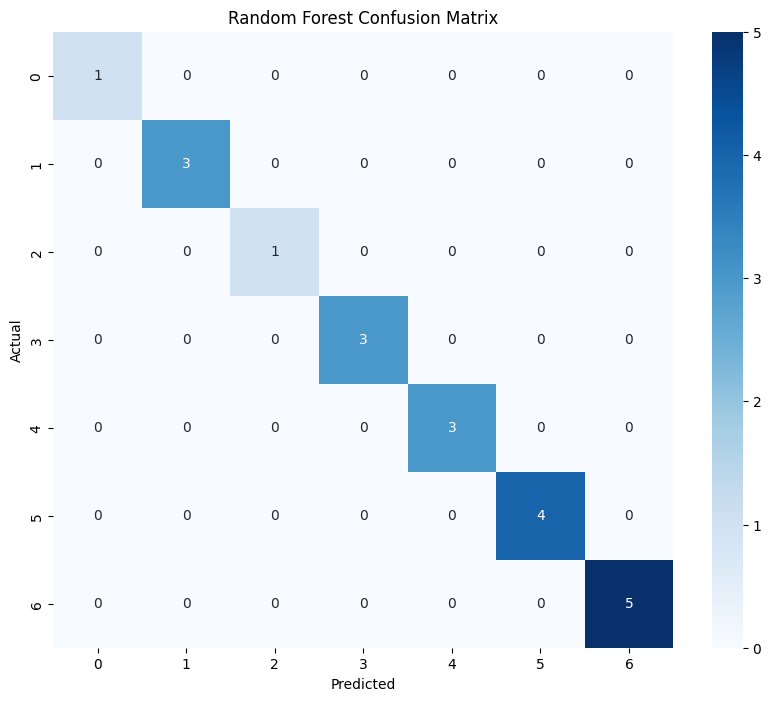

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Train XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:04:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



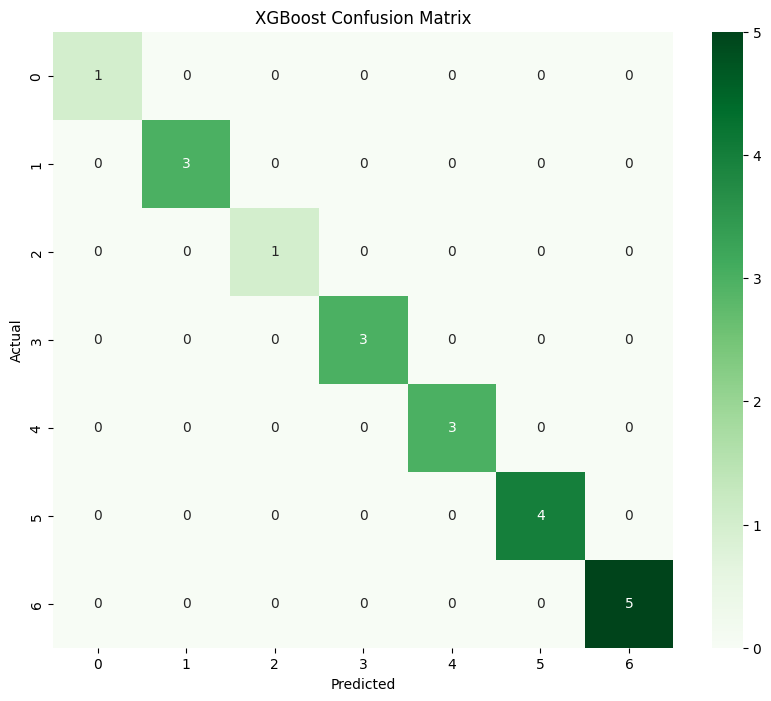

In [ ]:
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42,
                          use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", acc_xgb)
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10,8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Compare and select best model
best_model = rf_model if acc_rf > acc_xgb else xgb_model
print("Selected Best Model:", "Random Forest" if best_model == rf_model else "XGBoost")

Selected Best Model: XGBoost


# Save model, label encoder, and scaler

In [ ]:
joblib.dump(best_model, 'fertilizer_recommendation_model.pkl')
joblib.dump(le, 'fertilizer_label_encoder.pkl')
joblib.dump(scaler, 'fertilizer_scaler.pkl')
print("Model, Label Encoder, and Scaler saved successfully.")


Model, Label Encoder, and Scaler saved successfully.


In [ ]:
input_data = np.array([[30, 70, 40, 50, 30, 20]])
input_scaled = scaler.transform(input_data)
pred_encoded = best_model.predict(input_scaled)
pred_fertilizer = le.inverse_transform(pred_encoded)
print("Recommended Fertilizer:", pred_fertilizer[0])

Recommended Fertilizer: Urea


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
